### Sentiment Analysis for Underrepresented Languages: A Comparative Study Using CNN1D and FastText Embeddings

This study focuses on sentiment analysis for underrepresented languages, with a specific focus on **Afrikaans**. While sentiment analysis has been widely explored for high-resource languages such as English, fewer studies have focused on African and low-resource languages.

The aim of this experiment is to compare the performance of two CNN1D-based sentiment classification models:

1. A **baseline CNN1D model** trained without pretrained word embeddings.
2. A **CNN1D model enhanced with pretrained FastText word embeddings**.

The purpose of this comparison is to determine whether pretrained FastText embeddings can improve sentiment classification performance for Afrikaans text.

#### Dataset

The dataset used in this study is the **Afrikaans Sentiment Corpus**, which is publicly available on Hugging Face:

https://huggingface.co/datasets/michsethowusu/afrikaans-sentiments-corpus

This dataset contains Afrikaans text samples labelled according to sentiment categories and is used to train and evaluate the CNN1D sentiment classification models.

#### Dataset Citation

```shell
@dataset{afrikaans_sentiments_corpus,
  title={Afrikaans Sentiment Corpus},
  author={Mich-Seth Owusu},
  year={2025},
  url={https://huggingface.co/datasets/michsethowusu/afrikaans-sentiments-corpus}
}
```

---

#### Research Focus

The main focus of this study is to evaluate whether pretrained FastText word embeddings improve the performance of a CNN1D model for Afrikaans sentiment analysis.

The models are compared using the following evaluation metrics:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix

#### Proposed Models

The first model is a baseline CNN1D model that learns word representations directly from the training data. The second model uses pretrained FastText word embeddings to provide the CNN1D model with richer semantic word representations before classification.

By comparing these two models, the study investigates whether pretrained embeddings are useful for sentiment analysis in underrepresented languages such as Afrikaans.

#### Expected Contribution

This study contributes to NLP research by evaluating the impact of pretrained FastText embeddings on CNN1D-based sentiment classification for Afrikaans. The findings may help show whether pretrained word embeddings can improve performance in low-resource and underrepresented language settings.


In the following code cell, we will import all the necessary packages that will be used throughout this notebook.  
These include libraries for data handling, visualization, and model development.


In [150]:
import torch
import random
import warnings
import os
import json
import re
import time
import io
import html
import math

from collections import Counter, defaultdict
from helperfns.tables import tabulate_data
from pigmenta import PALETTES
from helperfns.visualization import plot_classification_report, plot_complicated_confusion_matrix
from helperfns.utils import hms_string
from torch import nn
from sklearn.utils import resample
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from ptflops import get_model_complexity_info

warnings.filterwarnings('ignore')
print("torch: ", torch.__version__)
print("numpy: ", np.__version__)
print("pandas: ", pd.__version__)

torch:  2.9.0+cu126
numpy:  2.4.6
pandas:  2.3.3


### Setting Seeds

In the following code cell, we will set a fixed seed value for all random operations to ensure **reproducibility** of the results.  
This helps guarantee that the model produces consistent outputs every time the notebook is run.


In [2]:
SEED = 23
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deteministic = True

### Device

In the following code cell, we will check for the availability of a **GPU** device and use it if possible.  
Utilizing a GPU can significantly accelerate model training and computations.


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Dataset Loading

The dataset is loaded into a **Pandas DataFrame** using `read_csv()`. It contains Afrikaans text samples and their corresponding sentiment labels.

**Objective:**
To compare a baseline CNN1D sentiment analysis model with a CNN1D model enhanced using pretrained **FastText word embeddings**, in order to determine whether pretrained embeddings improve performance for Afrikaans sentiment classification.




In [4]:
dataframe = pd.read_csv('afrikaans-sentiment-corpus.csv')
dataframe.head(2)

,Afrikaans,sentiment
0,Die lewe bestaan uit aksie (of stilte) oombl...,Negative
1,God Dislikes Hypocrites Too!,Negative


In the following code cell we are going to remove the `Na` values and null values as a way of cleaning the dataset.

In [5]:
if sum(dataframe.isna().any()):
  dataframe.dropna(inplace=True)
  dataframe.reset_index(drop=True, inplace=True)
dataframe.isna().any()
dataframe.head(2)

,Afrikaans,sentiment
0,Die lewe bestaan uit aksie (of stilte) oombl...,Negative
1,God Dislikes Hypocrites Too!,Negative


Next we are going to check the size of the dataset after this modification.

In [6]:
print(f"The dataset size is: {len(dataframe):,}")

The dataset size is: 1,500,000


### Data Cleaning

Before training the sentiment classification models, the Afrikaans text data is cleaned and preprocessed. This step helps remove noise, standardize the text, and improve consistency before model training.

The cleaning process prepares the text for both the **baseline CNN1D model** and the **CNN1D model using pretrained FastText embeddings**.

The following function is used to perform the cleaning process:



In [7]:
MENTION_HASHTAG_RE = re.compile(r"(@|#)([A-Za-z0-9_]+)")
EMAIL_RE = re.compile(r"([A-Za-z0-9]+[._-])*[A-Za-z0-9]+@[A-Za-z0-9-]+(\.[A-Za-z]{2,})+")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_TAG_RE = re.compile(r"<.*?>")
DIGIT_RE = re.compile(r"\d+")
PUNCT_RE = re.compile(r"[^\w\s']")
SPACE_RE = re.compile(r"\s+")

def clean_sentence(sent: str, lower: bool = True) -> str:
    sent = html.unescape(sent)
    if lower:
        sent = sent.lower()
    sent = HTML_TAG_RE.sub(" ", sent)
    sent = MENTION_HASHTAG_RE.sub(" ", sent)
    sent = EMAIL_RE.sub(" ", sent)
    sent = URL_RE.sub(" ", sent)
    sent = DIGIT_RE.sub(" ", sent)
    sent = PUNCT_RE.sub(" ", sent)
    sent = SPACE_RE.sub(" ", sent).strip()
    return sent

print("Unclean Example: ", dataframe.iloc[10].Afrikaans)
print("\n\nClean Example: ", clean_sentence(dataframe.iloc[10].Afrikaans))

Unclean Example:  Geloofshelden nader bekeken.


Clean Example:  geloofshelden nader bekeken


In the following code cell we are going to apply the `clean_sentence` function to our dataset so that it will be cleaned.

In [8]:
dataframe['text'] = dataframe.Afrikaans.apply(clean_sentence)
dataframe.head(2)

,Afrikaans,sentiment,text
0,Die lewe bestaan uit aksie (of stilte) oombl...,Negative,die lewe bestaan uit aksie of stilte oomblik t...
1,God Dislikes Hypocrites Too!,Negative,god dislikes hypocrites too


In this section, we will **visualize the dataset** using charts.  
First, we will examine the **distribution of labels** with a bar chart to understand how the text samples are distributed across different labels. 


In [9]:
dataframe["label"] = dataframe["sentiment"].map({
    "Positive": "positive",
    "Negative": "negative"
})
dataframe.head(2)

,Afrikaans,sentiment,text,label
0,Die lewe bestaan uit aksie (of stilte) oombl...,Negative,die lewe bestaan uit aksie of stilte oomblik t...,negative
1,God Dislikes Hypocrites Too!,Negative,god dislikes hypocrites too,negative


In [10]:
label_samples = dict(dataframe.label.value_counts())
label_samples

{'positive': np.int64(803944), 'negative': np.int64(696056)}

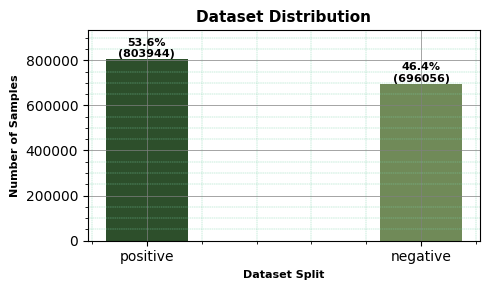

In [67]:
labels = list(label_samples.keys())
values = list(label_samples.values())

def fmt_bar(x, total):
    return '{:.1f}%\n({:.0f})'.format(x/total *100, x)
    
plt.figure(figsize=(5, 3), dpi=100)
plt.ylim(0, max(values) * 1.16)
bars = plt.bar(labels, values, width=.3, color=PALETTES.nature)
for index, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        fmt_bar(values[index], sum(values)),
        ha='center',
        va='bottom',
        fontsize=8,
        weight='bold'
    )

plt.xlabel('Dataset Split', fontsize=8, weight='bold')
plt.ylabel('Number of Samples', fontsize=8, weight='bold')
plt.title('Dataset Distribution', fontsize=11, weight='bold')
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

In the following code cell, we will **split the dataset into training, validation and testing sets**.  
The testing set will also be used for **model evaluation** during training and **validation** to assess performance.


In [71]:
train, test = train_test_split(dataframe, test_size=0.2, random_state=SEED)
train, valid = train_test_split(train, test_size=0.2, random_state=SEED)
train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)
valid.reset_index(drop=True, inplace=True)

In the following code cell we are going to check the distribution of data in each subset.

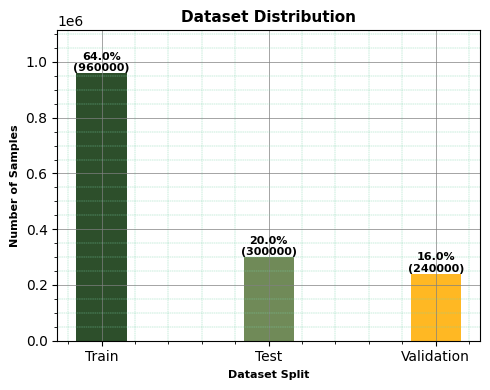

In [129]:
labels = ['Train', 'Test', 'Validation']
values = [len(train), len(test), len(valid)]

def fmt_bar(x, total):
    return '{:.1f}%\n({:.0f})'.format(x/total *100, x)
    
plt.figure(figsize=(5, 4), dpi=100 )
plt.ylim(0, max(values) * 1.16)
bars = plt.bar(labels, values, width=.3, color=PALETTES.nature)
for index, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        fmt_bar(values[index], sum(values)),
        ha='center',
        va='bottom',
        fontsize=8,
        weight='bold'
    )

plt.xlabel('Dataset Split', fontsize=8, weight='bold')
plt.ylabel('Number of Samples', fontsize=8, weight='bold')
plt.title('Dataset Distribution', fontsize=11, weight='bold')
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

In the following code cell we are going to check the label distribution of data.

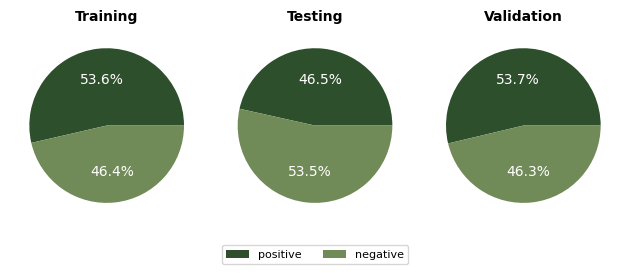

In [82]:
train_dist_label	= {i:0 for i in train.label.unique()}
for val in train.label:
  train_dist_label[val] += 1

test_dist_label	= {i:0 for i in test.label.unique()}
for val in test.label:
  test_dist_label[val] += 1

valid_dist_label	= {i:0 for i in valid.label.unique()}
for val in valid.label:
  valid_dist_label[val] += 1

fig, axes = plt.subplots(1, 3, dpi=100)

axes[0].pie(train_dist_label.values(), labels=train_dist_label.keys(), autopct='%1.1f%%',
            textprops={'color': 'white', 'fontsize':10}, radius=1,
            colors= PALETTES.nature
            )
axes[0].set_title("Training", fontsize=10 , weight="bold")

axes[1].pie(test_dist_label.values(), labels=test_dist_label.keys(), autopct='%1.1f%%',
            textprops={'color': 'white', 'fontsize':10}, radius=1,
            colors= PALETTES.nature
            )
axes[1].set_title("Testing", fontsize=10, weight="bold")

axes[2].pie(valid_dist_label.values(), labels=valid_dist_label.keys(), autopct='%1.1f%%',
            textprops={'color': 'white', 'fontsize':10 }, radius=1,
            colors= PALETTES.nature)
axes[2].set_title("Validation", fontsize=10, weight="bold")

fig.legend(train.label.value_counts().index, loc="lower center", bbox_to_anchor=(0.5, .2), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In the following code cell we are going to extract features and labels for the `training`, `testing` and `validation` subsets.

In [83]:
train_texts = train.text.values
train_labels = train.label.values

test_texts = test.text.values
test_labels = test.label.values

valid_texts = valid.text.values
valid_labels = valid.label.values

### Class Weight Computation

Since the Afrikaans sentiment dataset may contain imbalanced sentiment classes, class weights are computed and incorporated into the loss function. This helps the CNN1D model place greater emphasis on underrepresented sentiment classes by assigning a higher penalty to misclassification errors from minority-class samples.

The class weight for each sentiment class is computed as:

$$
w_c = \frac{N}{K \times n_c}
$$

Where:

$$
w_c
$$

is the weight assigned to sentiment class (c),

$$
N
$$

is the total number of training samples,

$$
K
$$

is the total number of sentiment classes, and

$$
n_c
$$

is the number of training samples belonging to sentiment class (c).

Both the **baseline CNN1D model** and the **CNN1D model using pretrained FastText embeddings** use the same class weighting strategy. These weights are passed to the weighted cross-entropy loss function during training.

This step is important because it reduces bias toward majority sentiment classes and helps ensure a fairer comparison between the baseline CNN1D model and the FastText-enhanced CNN1D model.


In [91]:
def get_class_weights(values):
    values = torch.tensor(values, dtype=torch.float32)
    total = values.sum()
    weights = total / (len(values) * values)
    return weights
    
class_weights = get_class_weights(list(label_samples.values()))
class_weights

tensor([0.9329, 1.0775])

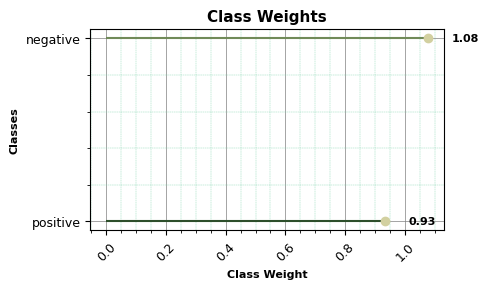

In [130]:
class_names = list(label_samples.keys())
def plot_lollipop_weights(ax, weights, class_names, title):
    sorted_indices = torch.argsort(weights)
    sorted_weights = weights[sorted_indices]
    sorted_names = [class_names[i] for i in sorted_indices]
    ax.hlines(
        y=sorted_names,
        xmin=0,
        xmax=sorted_weights.numpy(),
        color=PALETTES.nature[:len(sorted_names)]
    )
    ax.plot(
        sorted_weights.numpy(),
        sorted_names,
        "o",
        color=PALETTES.nature[20]
    )
    for x, y in zip(sorted_weights, sorted_names):
        ax.text(
            x.item() + 0.08,
            y,
            f"{x.item():.2f}",
            va="center",
            fontsize=8,
            weight="bold"
        )

    ax.set_xlabel("Class Weight", fontsize=8, weight="bold")
    ax.set_ylabel("Classes", fontsize=8, weight="bold")
    ax.set_title(title, fontsize=11, weight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.minorticks_on()
    ax.grid(which="major", color="gray", linestyle="-", linewidth=0.5)
    ax.grid(which="minor", color="#7ED4AD", linestyle="--", linewidth=0.3)

fig, axes = plt.subplots(1, 1, figsize=(5, 3), dpi=100)

plot_lollipop_weights(
    ax=axes,
    weights=class_weights,
    class_names=class_names,
    title="Class Weights"
)

plt.tight_layout()
plt.show()

Next, we will create a **Counter object** to store the word counts from the dataset.  
These counts will be used to **build our custom vocabulary** for subsequent analysis or modeling.


In [93]:
test_counter = Counter()
valid_counter = Counter()
train_counter = Counter()

for line in train_texts:
    train_counter.update(line.lower().split())

for line in test_texts:
    test_counter.update(line.lower().split())

for line in valid_texts:
    valid_counter.update(line.lower().split())

### Label Encoding Pipeline

The sentiment labels are originally stored in **text format**. Before training the CNN1D models, these labels are converted into numerical values so they can be used by the loss function during classification.

The process involves extracting the unique sentiment classes and creating a `labels_vocab` dictionary that maps each label to an integer value.

This mapping ensures that both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model** use the same label representation during training, validation, and testing.


In [94]:
labels_dict = {k: v for v, k in enumerate(train.label.unique())}
labels_dict

{'positive': 0, 'negative': 1}

The `label_pipeline` function takes a **text label** as input and returns its corresponding **integer representation**.  
This allows us to consistently convert all labels into numeric form for model training.


In [95]:
label_pipeline = lambda x: labels_dict[x]

### Vocabulary Construction

Next, a **Vocabulary class** is created using the `counter` object, which stores word-frequency counts from the training text.

We set `min_freq = 2`, meaning words that appear fewer than **2 times** are treated as unknown tokens. Special tokens such as `<PAD>` and `<UNK>` are also added to handle padding and unseen words.

This vocabulary is used to convert Afrikaans text into numerical token IDs for both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model**.


In [96]:
class vocab:
    def __init__(self, counter, min_freq=2, specials=('[unk]', '[pad]', '[sos]', '[eos]')):
        self.freqs = counter
        self.itos = list(specials)
        self.stoi = {}
        for token, freq in counter.items():
            if freq >= min_freq and token not in self.itos:
                self.itos.append(token)

        self.stoi = defaultdict(lambda: self.itos.index('[unk]')) 
        for idx, token in enumerate(self.itos):
            self.stoi[token] = idx

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        return self.stoi[token]

    def get_stoi(self):
        return self.stoi
    def get_itos(self):
        return self.itos

vocabulary = vocab(train_counter, min_freq=2, specials=('[unk]', '[pad]', '[sos]', '[eos]'))

### STOI: String-to-Integer Mapping

Next, a `stoi` dictionary is created to map each word in the vocabulary to a unique integer index.

This word-to-index mapping allows the Afrikaans text data to be converted into numerical token IDs, which can be passed into the CNN1D models.

The same `stoi` mapping is used for both model training and inference to ensure consistency between the baseline CNN1D model and the FastText-enhanced CNN1D model.


In [97]:
stoi = vocabulary.get_stoi()

### Text Pipeline

After tokenization, the text needs to be converted into numerical form so it can be processed by the CNN1D models.

The `text_pipeline` function performs this conversion by taking a sentence as input, tokenizing it into words, and mapping each word to its corresponding integer index from the `stoi` vocabulary.

Words that are not found in the vocabulary are mapped to the unknown token, such as `<UNK>`. This ensures that unseen words can still be handled during training, validation, testing, and inference.

The same text pipeline is used for both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model** to maintain a fair comparison.


In [23]:
def text_pipeline(x: str):
  values = list()
  tokens = x.lower().split(" ")
  for token in tokens:
    try:
      v = stoi[token]
    except KeyError as e:
      v = stoi['[unk]']
    values.append(v)
  return values

### Loading FastText Word Embeddings

In the next code cell, we load pretrained **FastText word vectors** from a static `.vec` file.

The FastText Afrikaans word embedding file used in this study is:

```text
C://Users//crisp//Documents//FastText//cc.af.300.vec
```

This file was downloaded from the official FastText pretrained word vectors page:

https://fasttext.cc/docs/en/crawl-vectors.html

The pretrained embeddings are used to initialize the embedding layer of the FastText-enhanced CNN1D model. This allows us to compare whether using pretrained word representations improves performance compared with the baseline CNN1D model, which learns its embeddings directly from the training data.

#### Citation

```shell
@inproceedings{grave2018learning,
  title={Learning Word Vectors for 157 Languages},
  author={Grave, Edouard and Bojanowski, Piotr and Gupta, Prakhar and Joulin, Armand and Mikolov, Tomas},
  booktitle={Proceedings of the International Conference on Language Resources and Evaluation (LREC 2018)},
  year={2018}
}
```

In [25]:
def load_vectors(fname, max_words=None):
    data = {}
    with io.open(fname, "r", encoding="utf-8", newline="\n", errors="ignore") as fin:
        n, d = map(int, fin.readline().split())
        for i, line in enumerate(fin):
            if max_words is not None and i >= max_words:
                break
            word, values = line.rstrip().split(" ", 1)
            data[word] = np.fromstring(values, sep=" ", dtype=np.float32)
    return data

fasttext_vectors = load_vectors(
    "C://Users//crisp//Documents//FastText//cc.af.300.vec"
)

### Creating the Embedding Matrix

Now that the pretrained **FastText Afrikaans word vectors** have been loaded, we create an embedding matrix that aligns with our vocabulary.

The embedding matrix maps each word index in the `stoi` vocabulary to its corresponding FastText vector. Words found in the FastText file are initialized with their pretrained embeddings, while words not found are handled using a default or randomly initialized vector.

This embedding matrix is then used to initialize the embedding layer of the **FastText-enhanced CNN1D model**, allowing us to compare it with the baseline CNN1D model that learns embeddings directly from the training data.

In [98]:
VOCAB_SIZE = len(stoi)
EMBEDDING_DIM = 300
EMBEDDING_MATRIX = torch.zeros((VOCAB_SIZE, EMBEDDING_DIM))
for word, index in stoi.items():
    vector = fasttext_vectors.get(word)
    try:
        if vector is not None:
            if isinstance(vector, torch.Tensor):
                EMBEDDING_MATRIX[index] = vector
            else:
                EMBEDDING_MATRIX[index] = torch.from_numpy(vector)
        else:
            EMBEDDING_MATRIX[index] = torch.zeros(EMBEDDING_DIM)
    except (IndexError, Exception):
        continue

In [28]:
assert VOCAB_SIZE == EMBEDDING_MATRIX.size(0), "They should be the same"

In the following code cell, we will **inspect the embedding matrix** by checking the vector representation for the word `"die"`.  
This helps verify that our embeddings have been correctly mapped to the vocabulary.


In [29]:
EMBEDDING_MATRIX[stoi['die']]

tensor([-6.0000e-04, -2.8260e-01, -7.5000e-03,  9.6000e-03,  2.9200e-02,
        -6.1000e-03, -1.1100e-02, -3.8100e-02, -1.9900e-02, -3.7000e-03,
         1.6700e-02,  8.1000e-03,  3.6400e-02, -2.4200e-02, -3.6000e-03,
         8.5000e-03, -1.8400e-02,  1.1480e-01, -1.5000e-03, -7.4600e-02,
         6.3000e-03, -1.4900e-02, -4.2000e-03,  1.1200e-02, -2.5600e-02,
        -1.2800e-02, -7.9000e-03, -2.4000e-03,  6.5000e-03,  2.0600e-02,
        -1.1900e-02, -1.1600e-02, -6.3000e-03,  3.0000e-03,  1.6600e-02,
        -8.8000e-03,  1.5300e-02,  6.4000e-03,  2.0000e-03,  4.8000e-03,
        -3.6000e-03,  1.3300e-02, -5.8000e-03,  1.2400e-02,  9.3000e-03,
         9.0000e-03,  1.4400e-02, -2.1000e-03,  2.5300e-02,  2.3600e-02,
         3.6700e-02,  1.0800e-02,  1.1300e-02, -2.5100e-02, -1.9500e-02,
        -7.3000e-03,  1.9400e-02,  9.8000e-03, -2.0300e-02, -1.0900e-02,
         1.1300e-02,  1.1800e-02, -4.1000e-03, -4.6000e-03,  8.9000e-03,
         0.0000e+00, -1.7000e-03, -1.0400e-02,  2.2

### Creating the Dataset for Training

In the following code cell, we define a custom dataset class called `SentimentDataset`.

This class takes the Afrikaans text samples and their corresponding sentiment labels as inputs. It applies the text pipeline to convert each text sample into numerical token IDs and prepares the labels for model training, validation, and testing.

The same dataset class is used for both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model** to ensure a fair comparison.

In [99]:
class SentimentDataset(torch.utils.data.Dataset):
  def __init__(self, labels, text):
    super(SentimentDataset, self).__init__()
    self.text = text
    self.labels = labels

  def __getitem__(self, index):
    return self.labels[index], self.text[index]

  def __len__(self):
    return len(self.text)

### Custom Collate Function

In the following code cell, we define a custom collate function called `tokenize_batch`.

This function prepares each batch before it is passed into the CNN1D models. It converts Afrikaans text samples into integer token IDs using the text pipeline, then pads or truncates each sequence to a fixed length so that all samples in the batch have the same shape.

The function returns the processed input tensors and their corresponding sentiment labels, ready for training, validation, or testing.

The same `tokenize_batch` function is used for both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model** to ensure a fair comparison.


In [100]:
def tokenize_batch(batch, max_len=300, position="start"):
    """
    position:
        - "start"  -> take first max_len tokens
        - "middle" -> take centered max_len tokens
        - "end"    -> take last max_len tokens
    """
    assert position in ["start", "middle", "end"], "position must be 'start', 'middle', or 'end'"
    labels_list, text_list = [], []
    for _label, _text in batch:
        labels_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int32)
        seq_len = len(processed_text)
        text_holder = torch.zeros(max_len, dtype=torch.int32)
        
        if seq_len <= max_len:
            text_holder[:seq_len] = processed_text
        else:
            if position == "start":
                selected = processed_text[:max_len]
            elif position == "end":
                selected = processed_text[-max_len:]
            elif position == "middle":
                mid = seq_len // 2
                half = max_len // 2
                start = max(0, mid - half)
                end = start + max_len
                selected = processed_text[start:end]
            text_holder = selected
        text_list.append(text_holder.unsqueeze(0))
    
    features = torch.cat(text_list, dim=0)
    labels_tensor = (
        torch.FloatTensor(labels_list)
        if len(set(labels_list)) == 2
        else torch.LongTensor(labels_list)
    )
    return labels_tensor, features


### Dataset Splits

In the following code cell, we create the dataset objects for the **training**, **validation**, and **testing** sets using the `SentimentDataset` class.

This step organizes the Afrikaans text samples and sentiment labels into separate datasets, ensuring that each split is properly prepared for input into both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model**.


In [33]:
train_dataset = SentimentDataset(train_labels, train_texts)
test_dataset = SentimentDataset(test_labels, test_texts)
valid_dataset = SentimentDataset(valid_labels, valid_texts)

### Data Loaders

In the following code cell, we create data loaders using the `DataLoader` class from `torch.utils.data`.

The data loaders handle batching, shuffling, and batch-level preprocessing through the custom `tokenize_batch` function.

For each dataset split, namely **training**, **validation**, and **testing**, separate iterators are created. These iterators prepare the Afrikaans sentiment data for input into both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model**.

Using the same data loaders for both models ensures that the comparison remains fair and consistent.


In [34]:
BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=tokenize_batch)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=tokenize_batch)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=tokenize_batch)

### Checking a Single Batch

In this step, we will inspect a **batches of data** from the DataLoader.  
This allows us to verify that the **features and labels** are correctly processed and ready for model training.


In [101]:
lbl, txt = next(iter(train_loader))

Checking a single batch of labels.

In [102]:
lbl

tensor([1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0.,
        1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0.,
        0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0.,
        0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
        0., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0.,
        0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0.,
        0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0.,
        0., 0.])

The first sentence in the batches.

In [103]:
txt[0]

tensor([  314,    26,  5900, 12683,  1034,    24,  6445,    65,   431,   542,
           87,  3312,  1094,    18,   438,   506,   560,    20,   101,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0, 

### CNN1D Sentiment Classification Model

In the following code cell, we implement the **CNN1D sentiment classification model** for Afrikaans text.

The model uses **1D convolutional layers** to extract local patterns from word embeddings. These patterns may include sentiment-bearing words, short phrases, and contextual word combinations that are useful for identifying sentiment in text.

Two versions of the CNN1D model are used in this study:

1. A **baseline CNN1D model** that learns its word embeddings during training.
2. A **FastText-enhanced CNN1D model** initialized with pretrained Afrikaans FastText word embeddings.

Both models use the same CNN1D architecture to ensure that the comparison focuses mainly on the impact of pretrained word embeddings.


In [38]:
class SentimentCNN(nn.Module):
  def __init__(self, vocab_size, embedding_dim, n_filters, filter_sizes, output_dim,
            dropout, pad_idx):
    super(SentimentCNN, self).__init__()
    self.embedding = nn.Sequential(
        nn.Embedding(vocab_size, embedding_dim, padding_idx = pad_idx)
    )
    self.convs = nn.Sequential(
        nn.ModuleList([
            nn.Conv1d(
                in_channels = embedding_dim,
                out_channels = n_filters,
                kernel_size = fs
              ) for fs in filter_sizes
        ])
    )
    self.out = nn.Sequential(
        nn.Linear(len(filter_sizes) * n_filters, output_dim)
    )
    self.dropout = nn.Dropout(dropout)

  def forward(self, text, lenght=None):
    embedded = self.embedding(text)
    embedded = embedded.permute(0, 2, 1)
    conved = [F.relu(conv(embedded)) for conv in self.convs[0]]
    pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
    cat = self.dropout(torch.cat(pooled, dim = 1))
    return self.out(cat)

In [46]:
N_FILTERS = 100
FILTER_SIZES = [3, 4, 5]
INPUT_DIM = VOCAB_SIZE
HIDDEN_DIM = 128
OUTPUT_DIM = 1 if len(labels_dict) == 2 else len(labels_dict)
DROPOUT = 0.5
PAD_IDX = stoi['[pad]']
plain_cnn = SentimentCNN(
 INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX
).to(device)

fasttext_cnn = SentimentCNN(
 INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX
).to(device)

fasttext_cnn

SentimentCNN(
  (embedding): Sequential(
    (0): Embedding(116663, 300, padding_idx=1)
  )
  (convs): Sequential(
    (0): ModuleList(
      (0): Conv1d(300, 100, kernel_size=(3,), stride=(1,))
      (1): Conv1d(300, 100, kernel_size=(4,), stride=(1,))
      (2): Conv1d(300, 100, kernel_size=(5,), stride=(1,))
    )
  )
  (out): Sequential(
    (0): Linear(in_features=300, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
)

### Model Complexity Analysis

In this section, model complexity is evaluated for the CNN1D sentiment classification models used in this study.

The analysis computes the number of parameters and estimates computational cost using MACs and FLOPs.

| Metric     | Description                                                                                        |
| ---------- | -------------------------------------------------------------------------------------------------- |
| Parameters | Total number of values in the model, including embedding, convolutional, and classification layers |
| MACs       | Multiply–Accumulate operations required during a forward pass                                      |
| FLOPs      | Approximate number of floating-point operations required during inference                          |

FLOPs are commonly estimated from MACs as:

$$
FLOPs \approx 2 \times MACs
$$

This analysis is important because two CNN1D models are compared in this study:

1. A **baseline CNN1D model** that learns its word embeddings during training.
2. A **FastText-enhanced CNN1D model** initialized with pretrained Afrikaans FastText embeddings.

Both models use the same CNN1D architecture, allowing the comparison to focus on whether pretrained FastText embeddings improve sentiment classification performance.

Evaluating model complexity helps determine the computational cost, model size, and suitability of each model for practical deployment, especially in low-resource and underrepresented language settings where lightweight models may be more appropriate.

Although FLOPs and MACs provide useful estimates of computational complexity, actual runtime may still vary depending on hardware, batch size, sequence length, memory access, and software optimization.


In [104]:
def count_params(model):
  total_params = sum([p.numel() for p in model.parameters()])
  trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return f'{total_params:,}', f'{trainable_params:,}', f'{total_params - trainable_params:,}'

def compute_flops(model, seq_len=300):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    if isinstance(model.embedding, nn.Sequential):
        embedding_layer = model.embedding[0]
    else:
        embedding_layer = model.embedding
    vocab_size = embedding_layer.num_embeddings
    def input_constructor(input_res):
        return {
            "text": torch.randint(
                low=0,
                high=vocab_size,
                size=(1, input_res[0]),
                dtype=torch.long,
                device=device
            )
        }
    macs, params = get_model_complexity_info(
        model,
        (seq_len,),
        input_constructor=input_constructor,
        as_strings=True,
        print_per_layer_stat=False,
        verbose=False
    )
    return macs, params

model_complexity_rows =[
    [
        "plain_cnn",
        *count_params(plain_cnn),
        *compute_flops(plain_cnn)
    ],
    [
        "fasttext_cnn",
        *count_params(fasttext_cnn),
        *compute_flops(fasttext_cnn)
    ],
    
]
tabulate_data(
    [
        "NAME",
        "TOTAL PARAMETERS",
        "TRAINABLE PARAMETERS",
        "NON-TRAINABLE PARAMETERS",
        "FLOPs (MACs)",
        "SHORTENED PARAMS",
    ],
    model_complexity_rows,
    "MOBILENETV3 MODELS' PARAMETERS"
)

Warning! No positional inputs found for a module, assuming batch size is 1.
Warning! No positional inputs found for a module, assuming batch size is 1.
MOBILENETV3 MODELS' PARAMETERS
+--------------+------------------+----------------------+--------------------------+--------------+------------------+
| NAME         | TOTAL PARAMETERS | TRAINABLE PARAMETERS | NON-TRAINABLE PARAMETERS | FLOPs (MACs) | SHORTENED PARAMS |
+--------------+------------------+----------------------+--------------------------+--------------+------------------+
| plain_cnn    |       35,359,501 |           35,359,501 |                        0 |  107.13 MMac |          35.36 M |
| fasttext_cnn |       35,359,501 |           35,359,501 |                        0 |  107.13 MMac |          35.36 M |
+--------------+------------------+----------------------+--------------------------+--------------+------------------+


### Loading FastText Embedding Vectors

In the following code cell, we load the pretrained **FastText Afrikaans word vectors** into the embedding layer of the FastText-enhanced CNN1D model.

The embedding matrix is assigned to the model using:

```python
model.embedding[0].weight.data.copy_(EMBEDDING_MATRIX)
```

This initializes the model with meaningful pretrained word representations instead of learning all embeddings from scratch.

This step is only applied to the **FastText-enhanced CNN1D model**. The baseline CNN1D model does not use pretrained embeddings, allowing us to compare whether FastText embeddings improve Afrikaans sentiment classification performance.


In [105]:
assert EMBEDDING_MATRIX.size(0) == VOCAB_SIZE, "This must match!"

In [106]:
fasttext_cnn.embedding[0].weight.data.copy_(EMBEDDING_MATRIX)

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0013, -0.0269,  0.0194,  ..., -0.0249,  0.0181,  0.0095]],
       device='cuda:0')

### Criterion and Optimizer

Next, we define the optimizer and loss function used to train the CNN1D sentiment classification models.

The **Adam optimizer** is used for gradient-based optimization and parameter updates during training.

Since this experiment is treated as a **binary sentiment classification task**, the loss function used is **`BCEWithLogitsLoss()`**. This loss function is suitable because it combines the sigmoid activation and binary cross-entropy loss in a single numerically stable operation.

To address class imbalance, a positive-class weight is incorporated into the loss function. The positive-class weight increases the penalty for misclassifying samples from the minority class, helping the model avoid bias toward the majority class.

The positive-class weight is computed as:

$$
pos_weight = \frac{w_{max}}{w_{min}}
$$

where:

$$
\begin{aligned}
w_{max} &= \text{weight of the minority class} \
w_{min} &= \text{weight of the majority class}
\end{aligned}
$$

In code, this is implemented as:

```python
pos_weight = torch.tensor([class_weights.max() / class_weights.min()]).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
```

This weighting strategy ensures that errors on the underrepresented class are penalized more heavily. As a result, both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model** are trained in a way that reduces bias toward the majority sentiment class.



In [107]:
optimizers = {
   "fasttext_cnn": torch.optim.Adam(
        fasttext_cnn.parameters(),
        lr=1e-3,
        weight_decay=1e-5,
        betas=(0.9, 0.999),
        eps=1e-8
    ),
    "plain_cnn": torch.optim.Adam(
        plain_cnn.parameters(),
        lr=1e-3,
        weight_decay=1e-5,
        betas=(0.9, 0.999),
        eps=1e-8
    )
}
pos_weight = torch.tensor([class_weights.max() /class_weights.min()]).to(device)
criterions = {
    "fasttext_cnn": nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device),
    "plain_cnn": nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device),
}

### Binary Accuracy Function

In the following code cell, we create a **binary accuracy** function to evaluate model performance.

Since this study uses **`BCEWithLogitsLoss()`**, the model outputs raw logits rather than probabilities. Therefore, the logits are first converted into probabilities using the sigmoid function. A threshold of `0.5` is then applied to convert the probabilities into binary class predictions.

The predicted labels are compared with the true sentiment labels to calculate the proportion of correctly classified samples.

This function is used to evaluate both the **baseline CNN1D model** and the **FastText-enhanced CNN1D model** during training, validation, and testing.


In [108]:
def binary_accuracy(y_preds, y_true):
  rounded_preds = torch.round(torch.sigmoid(y_preds))
  correct = (rounded_preds == y_true).float()
  return correct.sum() / len(correct)

### Training and Evaluation Functions

In the following code cell, we will define the **`train_fn`** and **`evaluate_fn`** functions:  

- **`train_fn`**: Handles the forward pass, loss computation, and backpropagation for model training.  
- **`evaluate_fn`**: Computes the loss and accuracy on validation or test data without updating the model weights.


In [61]:
def train_fn(model, iterator, optimizer, criterion, device):
  epoch_loss,epoch_acc = 0, 0
  model.train()
  for batch in iterator:
    y, X = batch
    X = X.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    predictions = model(X).squeeze(1)
    loss = criterion(predictions, y)
    acc = binary_accuracy(predictions, y)
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()
    epoch_acc += acc.item()
  return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate_fn(model, iterator, criterion, device):
  epoch_loss,epoch_acc = 0, 0
  model.eval()
  with torch.no_grad():
    for batch in iterator:
      y, X = batch
      X = X.to(device)
      y = y.to(device)
      predictions = model(X).squeeze(1)
      loss = criterion(predictions, y)
      acc = binary_accuracy(predictions, y)
      epoch_loss += loss.item()
      epoch_acc += acc.item()
  return epoch_loss / len(iterator), epoch_acc / len(iterator)

### Training Loop

During model training, we will **train the model** while continuously tracking its performance.  

The following `History` class serves as a **data structure to store the training history**, including metrics such as loss and accuracy for each epoch.


In [62]:
class History:
  def __init__(self):
    self.train_losses = list()
    self.train_acc = list()
    self.epoch_train_time = list()
    self.val_losses = list()
    self.val_acc = list()

  def add(self, train_loss:float, train_acc:float, val_loss:float, val_acc:float, elt:float):
    self.train_losses.append(train_loss)
    self.val_losses.append(val_loss)
    self.train_acc.append(train_acc)
    self.val_acc.append(val_acc)
    self.epoch_train_time.append(elt)

In the following code cell, we will define the **`run_train_loop` function**.  
This function orchestrates the **entire training process**, including running the training and evaluation steps for multiple epochs and updating the training history.


In [63]:
EPOCHS = 30
def train_model(model, model_name, train_iterator, optimizer, criterion, device, valid_iterator, epochs):
  best_valid_loss = float('inf')
  column_names = ["Set", "Loss", "Accuracy", "ETA (time)"]
  last_saved_epoch = 1

  history = History()
  training_start = time.time()
  for epoch in range(epochs):
    start = time.time()

    train_loss, train_acc = train_fn(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate_fn(model, valid_iterator, criterion, device)

    save_status = "(not saving)"
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      save_status = "(saving)"
      last_saved_epoch = epoch + 1
      torch.save(model.state_dict(), model_name)

    end = time.time()
    history.add(train_loss, train_acc, valid_loss, valid_acc, end-start)

    data_rows = [
        ["Train", f'{train_loss:.3f}', f'{train_acc * 100:.2f}%', hms_string(end-start)],
        ["Valid", f'{valid_loss:.3f}', f'{valid_acc * 100:.2f}%', "\t"]
    ]
    title = f"{model_name.replace('.pt', '')}: EPOCH {epoch+1:02}/{epochs}: {save_status}"
    print(title)
    for row in data_rows:
        print(" | ".join(row), ' |')
    print()

  training_end = time.time()
  return history, training_end - training_start, last_saved_epoch

In the following code cell we are going to run the training loop for the `Plain CNN` model.

In [137]:
print(f"\nTraining  plain_cnn...")
print("-" * 60)
checkpoint_name = "plain_cnn.pt"
plain_cnn_history,  plain_cnn_training_end, plain_cnn_last_saved_epoch = train_model(
    plain_cnn,
    checkpoint_name,
    train_loader,
    optimizers['plain_cnn'],
    criterions['plain_cnn'],
    device,
    valid_loader,
    epochs=EPOCHS
)


Training  plain_cnn...
------------------------------------------------------------
plain_cnn: EPOCH 01/30: (saving)
Train | 0.441 | 81.27% | 0:06:17.77  |
Valid | 0.465 | 80.00% | 	  |

plain_cnn: EPOCH 02/30: (saving)
Train | 0.430 | 81.90% | 0:06:19.38  |
Valid | 0.463 | 79.96% | 	  |

plain_cnn: EPOCH 03/30: (not saving)
Train | 0.424 | 82.23% | 0:06:12.99  |
Valid | 0.464 | 79.95% | 	  |

plain_cnn: EPOCH 04/30: (not saving)
Train | 0.419 | 82.57% | 0:06:17.28  |
Valid | 0.466 | 80.02% | 	  |

plain_cnn: EPOCH 05/30: (not saving)
Train | 0.414 | 82.78% | 0:06:18.38  |
Valid | 0.466 | 79.90% | 	  |

plain_cnn: EPOCH 06/30: (not saving)
Train | 0.409 | 83.08% | 0:06:21.88  |
Valid | 0.468 | 79.83% | 	  |

plain_cnn: EPOCH 07/30: (not saving)
Train | 0.405 | 83.22% | 0:06:21.02  |
Valid | 0.468 | 79.87% | 	  |

plain_cnn: EPOCH 08/30: (not saving)
Train | 0.401 | 83.45% | 0:06:20.00  |
Valid | 0.470 | 79.78% | 	  |

plain_cnn: EPOCH 09/30: (not saving)
Train | 0.397 | 83.62% | 0:06:

In [138]:
plain_cnn_checkpoint_name = checkpoint_name
print(f"Training completed.")
print(f"Best checkpoint saved as: {plain_cnn_checkpoint_name}")
print(f"Last saved epoch: {plain_cnn_last_saved_epoch}")
print("=" * 60)

Training completed.
Best checkpoint saved as: plain_cnn.pt
Last saved epoch: 2


In the following code cell we are going to run the training loop for the `FastText CNN` model.

In [139]:
print(f"\nTraining  fasttext_cnn...")
print("-" * 60)
fasttext_cnn_checkpoint_name = "fasttext_cnn.pt"
fasttext_cnn_history, fasttext_cnn_training_end, fasttext_cnn_last_saved_epoch = train_model(
    fasttext_cnn,
    fasttext_cnn_checkpoint_name,
    train_loader,
    optimizers['fasttext_cnn'],
    criterions['fasttext_cnn'],
    device,
    valid_loader,
    epochs=EPOCHS
)

print(f"Training completed.")
print(f"Best checkpoint saved as: {fasttext_cnn_checkpoint_name}")
print(f"Last saved epoch: {fasttext_cnn_last_saved_epoch}")
print("=" * 60)


Training  fasttext_cnn...
------------------------------------------------------------
fasttext_cnn: EPOCH 01/30: (saving)
Train | 0.361 | 85.38% | 0:06:17.78  |
Valid | 0.500 | 79.02% | 	  |

fasttext_cnn: EPOCH 02/30: (not saving)
Train | 0.359 | 85.48% | 0:06:26.59  |
Valid | 0.503 | 79.09% | 	  |

fasttext_cnn: EPOCH 03/30: (not saving)
Train | 0.358 | 85.51% | 0:06:18.82  |
Valid | 0.506 | 79.08% | 	  |

fasttext_cnn: EPOCH 04/30: (not saving)
Train | 0.356 | 85.60% | 0:06:15.96  |
Valid | 0.507 | 78.98% | 	  |

fasttext_cnn: EPOCH 05/30: (not saving)
Train | 0.355 | 85.67% | 0:06:16.85  |
Valid | 0.506 | 78.88% | 	  |

fasttext_cnn: EPOCH 06/30: (not saving)
Train | 0.354 | 85.71% | 0:06:22.08  |
Valid | 0.512 | 78.90% | 	  |

fasttext_cnn: EPOCH 07/30: (not saving)
Train | 0.352 | 85.78% | 0:06:17.08  |
Valid | 0.508 | 78.87% | 	  |

fasttext_cnn: EPOCH 08/30: (not saving)
Train | 0.352 | 85.78% | 0:07:17.83  |
Valid | 0.509 | 78.78% | 	  |

fasttext_cnn: EPOCH 09/30: (not savi

### Model Training Time and Complexity Summary

In the following code cell, a tabulated summary is presented for the training time and computational complexity of the CNN1D sentiment classification models.

The table includes the total training time, the epoch where the best checkpoint was saved, the number of trainable parameters, and the estimated MACs/FLOPs. This helps evaluate each model not only in terms of classification performance, but also in terms of training efficiency and computational cost.

| Model                       | Total Training Time | Best Checkpoint Epoch | Trainable Parameters |      MACs/FLOPs |
| --------------------------- | ------------------: | --------------------: | -------------------: | --------------: |
| Baseline CNN1D              |      To be computed |        To be recorded |       To be computed | To be estimated |
| CNN1D + FastText Embeddings |      To be computed |        To be recorded |       To be computed | To be estimated |

This summary provides an overview of the computational requirements of the two CNN1D sentiment classification models. Since both models use the same architecture, the comparison focuses on whether pretrained **FastText Afrikaans word embeddings** improve performance compared with a baseline CNN1D model that learns embeddings directly from the training data.

The training time and best checkpoint epoch help show how efficiently each model learns. The number of trainable parameters indicates the size of each model, while MACs and FLOPs provide an estimate of the computational cost required during inference.

This analysis supports the assessment of each model’s suitability for:

* Afrikaans sentiment classification
* Low-resource and underrepresented language NLP tasks
* Lightweight text classification systems
* Practical deployment in resource-constrained environments

Although MACs and FLOPs provide useful estimates of computational complexity, actual inference speed may vary depending on hardware, batch size, sequence length, memory access, and software optimization.


In [140]:
rows = [
    [
        f"fasttext_cnn",
        f"{EPOCHS}",
        f"{hms_string(fasttext_cnn_training_end)}",
        f"{fasttext_cnn_last_saved_epoch}",
        *compute_flops(fasttext_cnn)
    ], [
        f"plain_cnn",
        f"{EPOCHS}",
        f"{hms_string(plain_cnn_training_end)}",
        f"{plain_cnn_last_saved_epoch}",
        *compute_flops(plain_cnn)
    ],
    
]
tabulate_data(
    [
        "MODEL",
        "TOTAL EPOCHS",
        "TOTAL TRAINING TIME",
        "LAST SAVED EPOCH",
        "FLOPs (MACs)",
        "PARAMS"
    ],
    rows,
    "TOTAL TRAINING TIME"
)

Warning! No positional inputs found for a module, assuming batch size is 1.
Warning! No positional inputs found for a module, assuming batch size is 1.
TOTAL TRAINING TIME
+--------------+--------------+---------------------+------------------+--------------+---------+
| MODEL        | TOTAL EPOCHS | TOTAL TRAINING TIME | LAST SAVED EPOCH | FLOPs (MACs) |  PARAMS |
+--------------+--------------+---------------------+------------------+--------------+---------+
| fasttext_cnn |           30 |          3:15:18.14 |                1 |  107.13 MMac | 35.36 M |
| plain_cnn    |           30 |          3:09:43.14 |                2 |  107.13 MMac | 35.36 M |
+--------------+--------------+---------------------+------------------+--------------+---------+


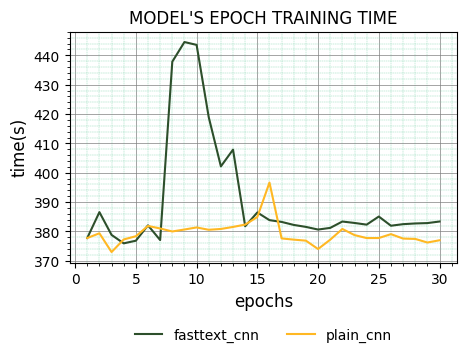

In [141]:
epochs = np.arange(1, EPOCHS + 1)
plt.figure(figsize=(5, 3), dpi=100)
plt.plot(epochs, fasttext_cnn_history.epoch_train_time, label="fasttext_cnn", color=PALETTES.nature[0])
plt.plot(epochs, plain_cnn_history.epoch_train_time, label="plain_cnn", color=PALETTES.nature[2])
plt.title("MODEL'S EPOCH TRAINING TIME", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("time(s)", fontsize=12)

plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.legend(loc="lower center",
    ncol=3, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.show()

Next, we will **visualize the training and validation losse** using a line graph.  

This plot shows how the loss evolved during training, helping us assess model convergence and detect potential overfitting.


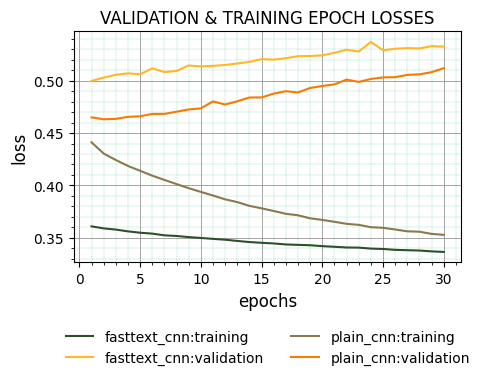

In [142]:
plt.figure(figsize=(5, 3), dpi=100)
plt.plot(epochs, fasttext_cnn_history.train_losses, label="fasttext_cnn:training", color=PALETTES.nature[0])
plt.plot(epochs, fasttext_cnn_history.val_losses, label="fasttext_cnn:validation", color=PALETTES.nature[2])
plt.plot(epochs, plain_cnn_history.train_losses, label="plain_cnn:training", color=PALETTES.nature[9])
plt.plot(epochs, plain_cnn_history.val_losses, label="plain_cnn:validation", color=PALETTES.nature[6])

plt.title("VALIDATION & TRAINING EPOCH LOSSES", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("loss", fontsize=12)
plt.legend(loc="lower center",
    ncol=2, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.5),
)
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.show()

Next, we will **visualize the training and validation accuracies** using a line graph.  
This plot shows how the model's accuracy evolved during training, allowing us to evaluate performance and monitor potential overfitting.


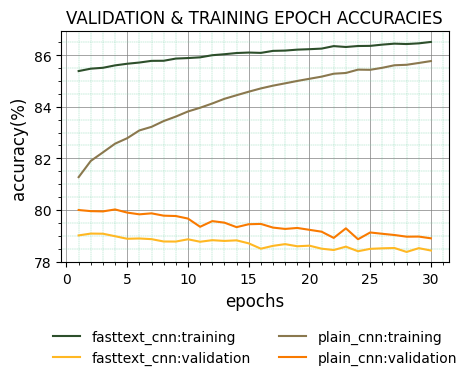

In [143]:
plt.figure(figsize=(5, 3), dpi=100)
plt.plot(epochs, [i * 100 for i in fasttext_cnn_history.train_acc], label="fasttext_cnn:training", color=PALETTES.nature[0])
plt.plot(epochs, [i * 100 for i in fasttext_cnn_history.val_acc], label="fasttext_cnn:validation", color=PALETTES.nature[2])
plt.plot(epochs, [i * 100 for i in plain_cnn_history.train_acc], label="plain_cnn:training", color=PALETTES.nature[9])
plt.plot(epochs, [i * 100 for i in plain_cnn_history.val_acc], label="plain_cnn:validation", color=PALETTES.nature[6])

plt.title("VALIDATION & TRAINING EPOCH ACCURACIES", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("accuracy(%)", fontsize=12)
plt.legend(loc="lower center",
    ncol=2, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.5),
)
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.show()


### Best Model Evaluation

In the following code cell, a function is defined to evaluate the best saved checkpoint for each CNN1D sentiment classification model.

The function performs inference on the independent test dataset and computes key performance metrics, including test loss, test accuracy, and inference time. This provides an unbiased estimate of how well each model generalizes to unseen Afrikaans sentiment data.

| Metric         | Description                                                           |
| -------------- | --------------------------------------------------------------------- |
| Test Loss      | Measures the model’s error on unseen test samples                     |
| Test Accuracy  | Shows the percentage of correctly classified sentiment samples        |
| Inference Time | Measures how long the model takes to make predictions on the test set |

This evaluation is applied to:

* Baseline CNN1D model
* CNN1D model with pretrained FastText embeddings

The best checkpoint is selected based on the lowest validation loss recorded during training. After training is complete, the best checkpoint for each model is loaded and evaluated on the test dataset.

This evaluation step is important because it allows a fair comparison between the baseline CNN1D model and the FastText-enhanced CNN1D model. The results help determine whether pretrained FastText Afrikaans word embeddings improve sentiment classification performance compared with learning embeddings directly from the training data.

Evaluating the best checkpoint also supports the assessment of each model’s predictive performance, inference efficiency, and suitability for lightweight sentiment analysis in underrepresented language settings.


In [144]:
test_samples = len(test_loader.dataset)
test_samples

300000

In [145]:
def evaluate_best_model(model, checkpoint_path, test_iterator, criterion, device):
    model.eval()
    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device, weights_only=True)
    )
    test_loss, test_acc = evaluate_fn(
        model,
        test_iterator,
        criterion,
        device
    )
    return f"{test_loss:.2f}", f"{test_acc * 100:.2f}"

rows = []
accuracies = {}
for model in ['plain_cnn','fasttext_cnn']:
    start = time.time()
    loss, acc = evaluate_best_model(
        model= plain_cnn if model == "plain_cnn" else fasttext_cnn,
        checkpoint_path=f'{model}.pt',
        test_iterator=test_loader,
        criterion=criterions[model],
        device=device
    )
    accuracies[model] = acc
    end = time.time()
    rows.append([
        model,
        loss,
        acc,
        f"{test_samples:,}",
        hms_string(end - start)
    ])
    
tabulate_data(
    ["NAME", "LOSS", "ACCURACY (%)", "SAMPLES", "INFERENCE TIME"],
    rows,
    "BEST CHECKPOINTED MOBILENETV3 MODEL PERFORMANCE"
)

BEST CHECKPOINTED MOBILENETV3 MODEL PERFORMANCE
+--------------+------+--------------+---------+----------------+
| NAME         | LOSS | ACCURACY (%) | SAMPLES | INFERENCE TIME |
+--------------+------+--------------+---------+----------------+
| plain_cnn    | 0.46 |        79.97 | 300,000 |     0:00:50.73 |
| fasttext_cnn | 0.50 |        79.03 | 300,000 |     0:00:49.73 |
+--------------+------+--------------+---------+----------------+


### Wilson Score Confidence Intervals

In the following code cell, the **90%**, **95%**, and **99%** confidence intervals are computed for the test accuracy of the CNN1D sentiment classification models using the **Wilson Score Interval** method.

This analysis provides a statistical estimate of how reliable the observed test accuracy is by showing the range within which the true accuracy is likely to fall at different confidence levels.

The confidence intervals are computed for:

| Model                       | Confidence Intervals Computed |
| --------------------------- | ----------------------------- |
| Baseline CNN1D              | 90%, 95%, and 99%             |
| CNN1D + FastText Embeddings | 90%, 95%, and 99%             |

The Wilson Score Interval is useful because test accuracy is calculated from a finite testing subset. Therefore, the observed accuracy may not perfectly represent the true performance of the model on unseen Afrikaans sentiment data.

The Wilson Score Interval is computed as:

$$
CI = \frac{\hat{p} + \frac{z^2}{2n} \pm z \sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}
$$

where:

$$
\begin{aligned}
\hat{p} &= \text{observed test accuracy} \
n &= \text{number of test samples} \
z &= \text{z-score for the selected confidence level}
\end{aligned}
$$

This step supports a more reliable comparison between the **baseline CNN1D model** and the **FastText-enhanced CNN1D model**. It helps determine whether any observed improvement from pretrained FastText embeddings is meaningful or may be affected by uncertainty in the test set.


In [152]:
def wilson_score_interval(accuracy, n, confidence=0.95):
    """
    Compute Wilson Score Confidence Interval.

    Parameters:
    accuracy (float): Model accuracy between 0 and 1
    n (int): Number of test samples
    confidence (float): Confidence level (default = 0.95)

    Returns:
    tuple: (lower_bound, upper_bound)
    """
    z_values = {
        0.90: 1.645,
        0.95: 1.96,
        0.99: 2.576
    }
    z = z_values.get(confidence, 1.96)
    denominator = 1 + (z**2 / n)
    centre = accuracy + (z**2 / (2 * n))
    margin = z * math.sqrt(
        (accuracy * (1 - accuracy) / n) +
        (z**2 / (4 * n**2))
    )
    lower = (centre - margin) / denominator
    upper = (centre + margin) / denominator
    return lower, upper

In [154]:
confidence_levels = {
    0.90: 1.645,
    0.95: 1.960,
    0.99: 2.576
}

for m, acc in accuracies.items():
    ci_rows = []
    accuracy = float(acc) / 100.0
    n = test_samples
    for confidence, z_score in confidence_levels.items():
        lower, upper = wilson_score_interval(
            accuracy,
            n,
            confidence=confidence
        )
    
        ci_rows.append([
            f"{int(confidence * 100)}%",
            f"{accuracy * 100:.2f}",
            f"{z_score:.3f}",
            f"{lower * 100:.2f}",
            f"{upper * 100:.2f}",
        ])
    
    tabulate_data(
        ["Confidence", "Accuracy (%)", "Z-score", "Lower CI (%)", "Upper CI (%)"],
        ci_rows,
        f"WILSON SCORE CONFIDENCE INTERVALS for '{m}'"
    )
    
    print("\n\n")

WILSON SCORE CONFIDENCE INTERVALS for 'plain_cnn'
+------------+--------------+---------+--------------+--------------+
| Confidence | Accuracy (%) | Z-score | Lower CI (%) | Upper CI (%) |
+------------+--------------+---------+--------------+--------------+
| 90%        |        79.97 |   1.645 |        79.85 |        80.09 |
| 95%        |        79.97 |   1.960 |        79.83 |        80.11 |
| 99%        |        79.97 |   2.576 |        79.78 |        80.16 |
+------------+--------------+---------+--------------+--------------+



WILSON SCORE CONFIDENCE INTERVALS for 'fasttext_cnn'
+------------+--------------+---------+--------------+--------------+
| Confidence | Accuracy (%) | Z-score | Lower CI (%) | Upper CI (%) |
+------------+--------------+---------+--------------+--------------+
| 90%        |        79.03 |   1.645 |        78.91 |        79.15 |
| 95%        |        79.03 |   1.960 |        78.88 |        79.18 |
| 99%        |        79.03 |   2.576 |        78.84 |

### Testing Evaluation Using Confusion Matrix and Classification Report

In the following code cell, we evaluate the best checkpointed models on the testing subset.

The evaluation uses a **confusion matrix (CM)** and a **classification report (CR)** to provide a detailed comparison of the model predictions against the true sentiment labels.

The confusion matrix shows how many samples were correctly and incorrectly classified for each class, while the classification report summarizes key performance metrics such as precision, recall, F1-score, and support.

This evaluation is applied to both:

* Baseline CNN1D model
* CNN1D model with pretrained FastText embeddings

Using the same testing subset for both models ensures a fair comparison and helps determine whether pretrained FastText embeddings improve sentiment classification performance for Afrikaans text.


In [158]:
def get_predictions(model, iterator, device):
  model.eval()
  labels = []
  predictions = []
  with torch.no_grad():
    for (y, X) in iterator:
      X = X.to(device)
      y_pred = model(X).squeeze(1)
      y_prob = F.sigmoid(y_pred).round().long()
      labels.append(y.cpu())
      predictions.append(y_prob.cpu())
  labels = torch.cat(labels, dim = 0).numpy()
  predictions = torch.cat(predictions, dim = 0).numpy()
  return labels, predictions
    
plain_cnn_y_true, plain_cnn_y_preds = get_predictions(plain_cnn, test_loader, device)
fasttext_cnn_y_true, fasttext_cnn_y_preds = get_predictions(fasttext_cnn, test_loader, device)

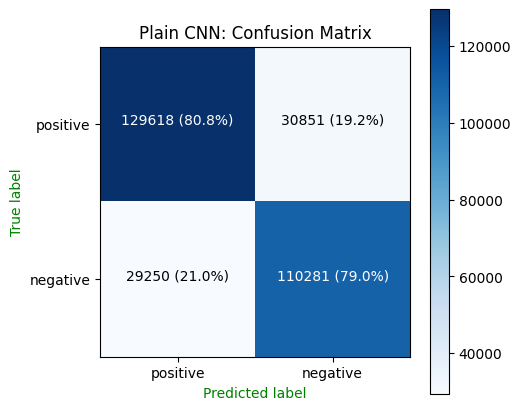

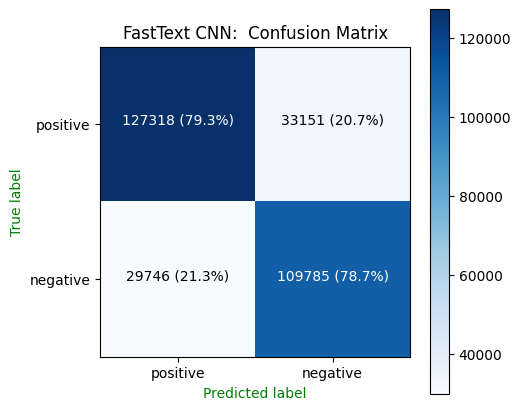

In [159]:
plot_complicated_confusion_matrix(plain_cnn_y_true, plain_cnn_y_preds,
  labels_dict.keys(), fontsize=10, figsize=(5, 5),  title="Plain CNN: Confusion Matrix"
)
plot_complicated_confusion_matrix(fasttext_cnn_y_true, fasttext_cnn_y_preds,
  labels_dict.keys(), fontsize=10, figsize=(5, 5),  title="FastText CNN:  Confusion Matrix"
)

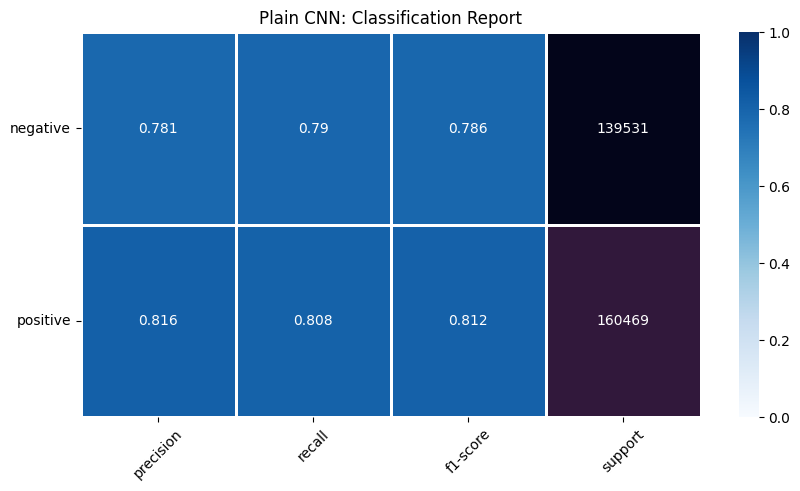

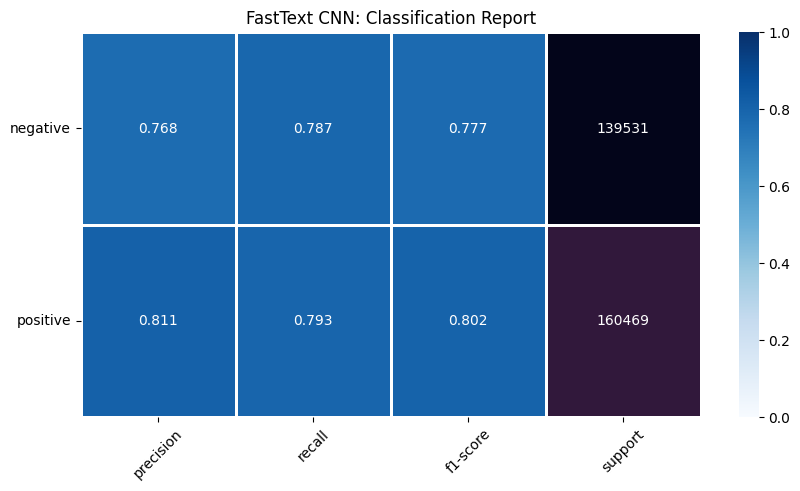

In [160]:
fig, ax = plot_classification_report(
    plain_cnn_y_true, plain_cnn_y_preds,
    title='Plain CNN: Classification Report',
    figsize=(10, 5), dpi=100,
    target_names = labels_dict.keys()
)
fig, ax = plot_classification_report(
    fasttext_cnn_y_true, fasttext_cnn_y_preds,
    title='FastText CNN: Classification Report',
    figsize=(10, 5), dpi=100,
    target_names = labels_dict.keys()
)

### Model Sizes

In the following code cell, the saved model file sizes are calculated for the trained CNN1D sentiment classification models.

This analysis is used to compare the storage requirements of:

* Baseline CNN1D model
* CNN1D model with pretrained FastText embeddings

Model size is important because it helps determine how lightweight each model is and whether it is suitable for deployment in resource-constrained environments.

Comparing the saved file sizes also helps show whether adding pretrained FastText embeddings increases the storage cost of the model compared with the baseline CNN1D model that learns embeddings directly from the training data.


In [162]:
def model_size(path: str):
    if not os.path.exists(path):
        return "File not found"
    num = os.path.getsize(path)
    for unit in ["bytes", "KB", "MB", "GB", "TB"]:
        if num < 1024.0:
            return f"{num:.1f} {unit}"
        num /= 1024.0

rows = []
rows.append([
    "fasttext_cnn.pt",
    model_size('fasttext_cnn.pt')
])
rows.append([
    "plain_cnn.pt",
    model_size("plain_cnn.pt")
])

tabulate_data(
    ["Model File", "Size"],
    rows,
    "MODEL FILE DISK SIZES"
)

MODEL FILE DISK SIZES
+-----------------+----------+
| Model File      |     Size |
+-----------------+----------+
| fasttext_cnn.pt | 134.9 MB |
| plain_cnn.pt    | 134.9 MB |
+-----------------+----------+
